In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/



Import additional libraries


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2
from skimage.measure import shannon_entropy
from sklearn.preprocessing import MinMaxScaler

In [3]:
ROOT = "/content/drive/My Drive/Eye Disease/Dataset"

CSV_PATH = os.path.join(ROOT, "full_df.csv")

TRAIN_DIR = os.path.join(ROOT, "ODIR-5K", "ODIR-5K" ,"Training Images")

TEST_DIR = os.path.join(ROOT, "ODIR-5K","ODIR-5K", "Testing Images")

PREPROCESS_DIR = os.path.join(ROOT, "preprocessed_images")

In [4]:
train_df = pd.read_csv(os.path.join(ROOT, "train.csv"))
val_df   = pd.read_csv(os.path.join(ROOT, "validation.csv"))
test_df  = pd.read_csv(os.path.join(ROOT, "test.csv"))

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (4474, 21)
Validation: (959, 21)
Test: (959, 21)


Define Quality Metric Functions

In [5]:
# IMAGE QUALITY METRICS

def calculate_blur(image):
    """
    Blur Score using Variance of Laplacian.
    Higher value = Sharper Image
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def calculate_brightness(image):
    """
    Average brightness.
    Higher value = Brighter Image
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)


def calculate_contrast(image):
    """
    Standard deviation of pixel intensities.
    Higher value = Better Contrast
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return np.std(gray)


def calculate_entropy(image):
    """
    Shannon Entropy.
    Higher value = More information/content.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return shannon_entropy(gray)

Compute Metrics for All Images

In [6]:
quality_metrics = []

image_files = sorted(os.listdir(PREPROCESS_DIR))

print(f"Total Images: {len(image_files)}")

for image_name in tqdm(image_files):

    image_path = os.path.join(PREPROCESS_DIR, image_name)

    image = cv2.imread(image_path)

    if image is None:
        continue

    blur = calculate_blur(image)
    brightness = calculate_brightness(image)
    contrast = calculate_contrast(image)
    entropy = calculate_entropy(image)

    quality_metrics.append({
        "filename": image_name,
        "blur": blur,
        "brightness": brightness,
        "contrast": contrast,
        "entropy": entropy
    })

quality_df = pd.DataFrame(quality_metrics)

quality_df.head()

Total Images: 6392


100%|██████████| 6392/6392 [05:45<00:00, 18.49it/s]


,filename,blur,brightness,contrast,entropy
0,0_left.jpg,258.655184,77.837914,41.670421,4.678783
1,0_right.jpg,88.706981,46.026424,26.583894,5.153259
2,1005_right.jpg,272.941360,95.694637,52.843309,5.222380
3,1006_left.jpg,93.447870,27.825661,28.463785,5.356987
4,1006_right.jpg,106.537872,39.769985,39.201666,5.068160


Verify Results

In [ ]:
print(quality_df.shape)

quality_df.describe()

(6392, 5)


,blur,brightness,contrast,entropy
count,6392.000000,6392.000000,6392.000000,6392.000000
mean,280.891760,79.973624,48.229212,5.906298
std,202.833724,25.206348,13.574529,0.430365
min,2.814586,5.228615,6.301911,3.815665
25%,138.398417,62.040777,38.893690,5.647810
50%,234.311249,78.582108,47.460530,5.947516
75%,366.181010,97.247593,57.275561,6.193706
max,2594.961178,188.285507,102.495922,7.422370


Saving Raw Metrics

In [ ]:
quality_df.to_csv(
    os.path.join(ROOT, "quality_metrics.csv"),
    index=False
)

print("quality_metrics.csv saved successfully.")

quality_metrics.csv saved successfully.


NOrmalizing all the metrics  then combine them in next step

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy of the original dataframe
normalized_df = quality_df.copy()

# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Columns to normalize
quality_columns = ["blur", "brightness", "contrast", "entropy"]

# Normalize the selected columns
normalized_df[quality_columns] = scaler.fit_transform(
    normalized_df[quality_columns]
)

# Display first few rows
normalized_df.head()

,filename,blur,brightness,contrast,entropy
0,0_left.jpg,0.098698,0.396649,0.367679,0.239309
1,0_right.jpg,0.033136,0.222870,0.210845,0.370863
2,1005_right.jpg,0.104210,0.494196,0.483828,0.390028
3,1006_left.jpg,0.034965,0.123443,0.230387,0.427349
4,1006_right.jpg,0.040014,0.188692,0.342015,0.347269


Verify that normalization worked

In [ ]:
normalized_df.describe()

,blur,brightness,contrast,entropy
count,6392.000000,6392.000000,6392.000000,6392.000000
mean,0.107277,0.408316,0.435862,0.579652
std,0.078249,0.137697,0.141116,0.119324
min,0.000000,0.000000,0.000000,0.000000
25%,0.052306,0.310352,0.338813,0.507983
50%,0.089307,0.400714,0.427871,0.591080
75%,0.140180,0.502680,0.529905,0.659339
max,1.000000,1.000000,1.000000,1.000000


Compute the Final Quality Score (Weighted Average)

In [ ]:
# Defining weights
blur_weight = 0.40
brightness_weight = 0.20
contrast_weight = 0.20
entropy_weight = 0.20

# Calculating final quality score
normalized_df["quality_score"] = (
    blur_weight * normalized_df["blur"] +
    brightness_weight * normalized_df["brightness"] +
    contrast_weight * normalized_df["contrast"] +
    entropy_weight * normalized_df["entropy"]
)

# Displaying the first few rows
normalized_df.head()

,filename,blur,brightness,contrast,entropy,quality_score
0,0_left.jpg,0.098698,0.396649,0.367679,0.239309,0.240207
1,0_right.jpg,0.033136,0.222870,0.210845,0.370863,0.174170
2,1005_right.jpg,0.104210,0.494196,0.483828,0.390028,0.315294
3,1006_left.jpg,0.034965,0.123443,0.230387,0.427349,0.170222
4,1006_right.jpg,0.040014,0.188692,0.342015,0.347269,0.191601


Check the quality score statistics

In [ ]:
normalized_df["quality_score"].describe()

,quality_score
count,6392.000000
mean,0.327677
std,0.091633
min,0.008251
25%,0.263920
50%,0.320697
75%,0.389566
max,0.680010


Save the Final File

In [ ]:
quality_scores_path = os.path.join(ROOT, "quality_scores.csv")

normalized_df.to_csv(
    quality_scores_path,
    index=False
)

print(f"Quality scores saved successfully at:\n{quality_scores_path}")

Quality scores saved successfully at:
/content/drive/My Drive/Eye Disease/Dataset/quality_scores.csv


Distribution of Quality Scores

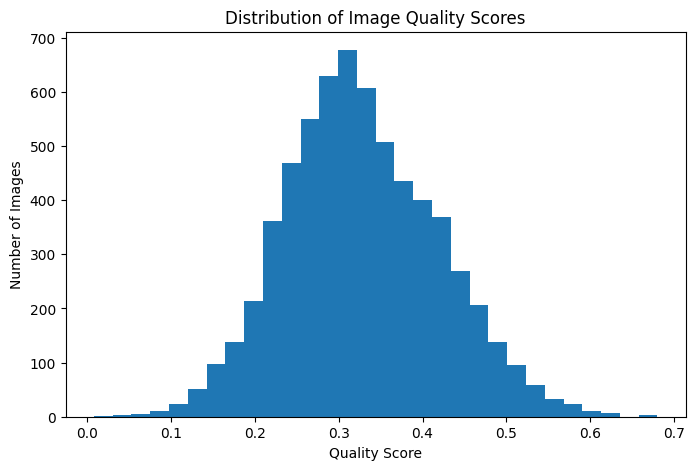

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(normalized_df["quality_score"], bins=30)

plt.title("Distribution of Image Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Images")

plt.show()

Highest Quality Images

In [ ]:
top5 = normalized_df.sort_values(
    by="quality_score",
    ascending=False
).head(5)

top5

,filename,blur,brightness,contrast,entropy,quality_score
3232,3156_right.jpg,0.590759,0.683156,0.762450,0.772926,0.680010
3681,3378_left.jpg,1.000000,0.340369,0.393710,0.629482,0.672712
935,1643_left.jpg,0.605089,0.588681,0.724719,0.779447,0.660605
4466,4216_right.jpg,0.756360,0.519960,0.567121,0.693769,0.658714
4640,4300_left.jpg,0.477371,0.805821,0.828627,0.565104,0.630859
